In [1]:
#to start from root folder
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

In [2]:
#importing to first see if our ftns are working fine
import numpy as np
from src.color_spaces import rgb_to_lms, lms_to_rgb

In [3]:
# fake a tiny "image" — 1 pixel, some arbitrary RGB value
test_pixel = np.array([[[0.5, 0.2, 0.8]]])  # shape (1,1,3)

lms = rgb_to_lms(test_pixel)
back_to_rgb = lms_to_rgb(lms)

print(test_pixel)
print(back_to_rgb)

[[[0.5 0.2 0.8]]]
[[[0.5 0.2 0.8]]]


In [4]:
#success!

In [5]:
#let's test our simulation on a real image now, time for the test!!
from src.utils import load_image_rgb_normalized, save_image_rgb_normalized
from src.simulate import simulate_cvd, PROTANOPIA_MATRIX, TRITANOPIA_MATRIX, DEUTERANOPIA_MATRIX

In [6]:
img = load_image_rgb_normalized('D:/downloads/colorblind-accessibility/data/test_images/74_img.jpg')
simulated = simulate_cvd(img, PROTANOPIA_MATRIX)
save_image_rgb_normalized(simulated, 'D:/downloads/colorblind-accessibility/data/test_imagesprotanopia_output.jpg')

In [7]:
#gonna run some checks to see file save
import os

In [8]:
print(os.getcwd())  # is this the project root, or somewhere else?
print(os.path.exists('data/test_images'))  # does the path even resolve from here?

d:\downloads\colorblind-accessibility\notebooks
False


In [9]:
#we'll be using absolute paths for file saves to avoid mishaps
#visualizing our experiment
import matplotlib.pyplot as plt

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.1980263420688228..1.0001728277936046].


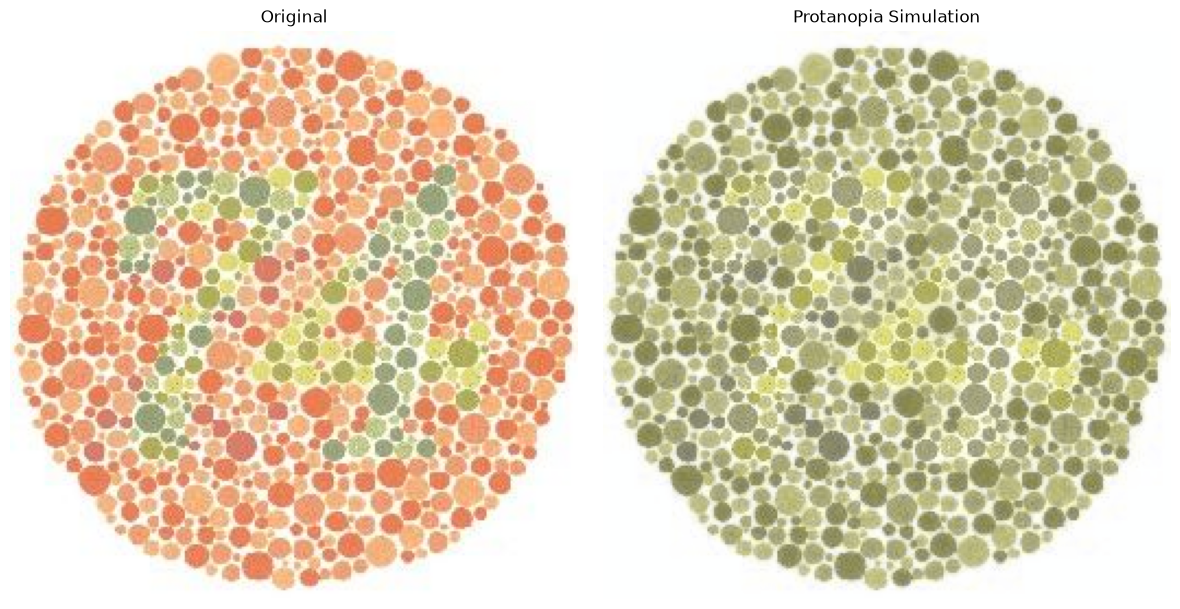

In [10]:
#comparing protanopia with original image
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(img)
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(simulated)
axes[1].set_title('Protanopia Simulation')
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [11]:
img = load_image_rgb_normalized('D:/downloads/colorblind-accessibility/data/test_images/74_img.jpg')
simulated = simulate_cvd(img, DEUTERANOPIA_MATRIX)
save_image_rgb_normalized(simulated, 'D:/downloads/colorblind-accessibility/data/test_imagesdeuteranopia_output.jpg')

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.1852168089041222..1.0025403257290544].


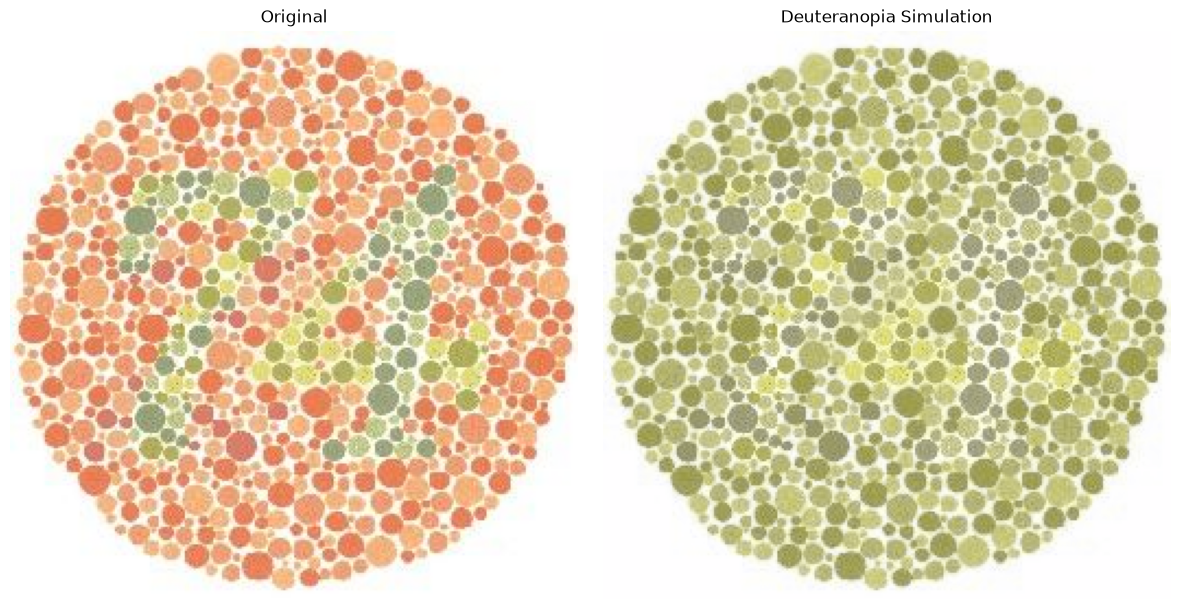

In [12]:
#comparing deuteranopia with original image
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(img)
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(simulated)
axes[1].set_title('Deuteranopia Simulation')
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [13]:
img = load_image_rgb_normalized('D:/downloads/colorblind-accessibility/data/test_images/74_img.jpg')
simulated = simulate_cvd(img, TRITANOPIA_MATRIX)
save_image_rgb_normalized(simulated, 'D:/downloads/colorblind-accessibility/data/test_imagestritanopia_output.jpg')

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.425725899390536..1.3424562997995648].


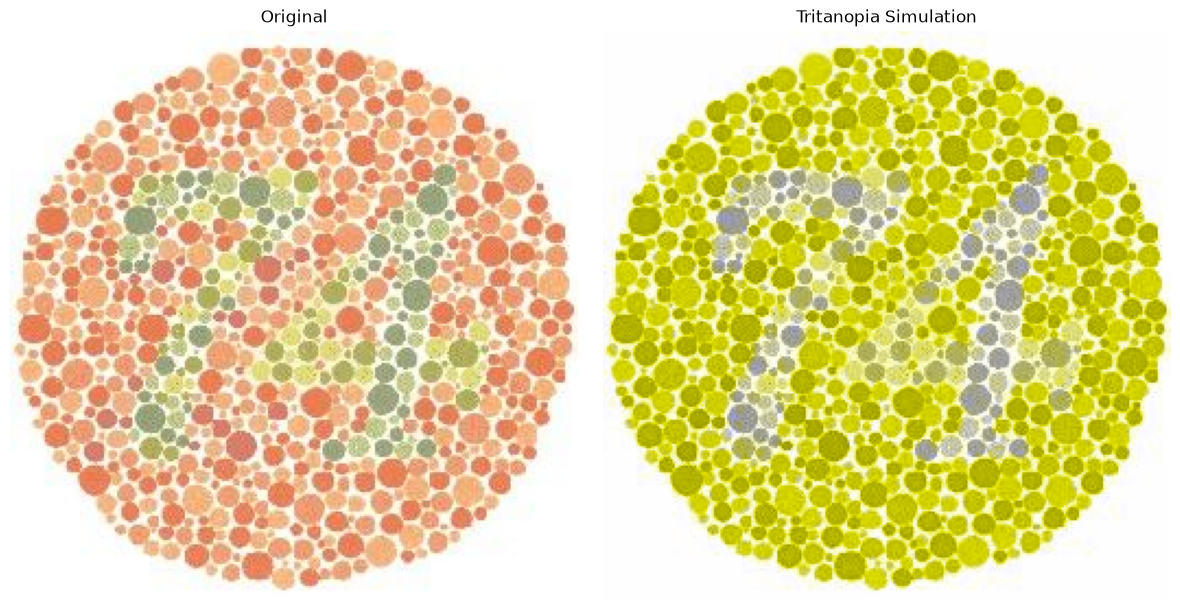

In [14]:
#comparing tritanopia with original image
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(img)
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(simulated)
axes[1].set_title('Tritanopia Simulation')
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [15]:
#tritanopia shouldn't be changing the red/orange this drastically. since we've been implementing the simplified version of Brettel method, this seems to be expected.

In [16]:
#further diagnosing by isolating orange

orange = np.array([[[1.0, 0.65, 0.0]]])  # roughly orange, normalized

lms = rgb_to_lms(orange)
print("LMS:", lms)

sim_lms = lms @ TRITANOPIA_MATRIX.T
print("Simulated LMS:", sim_lms)

sim_rgb = lms_to_rgb(sim_lms)
print("Simulated RGB (unclipped):", sim_rgb)

LMS: [[[46.167865   21.10666     0.14975745]]]
Simulated LMS: [[[46.167865   21.10666    -1.36972265]]]
Simulated RGB (unclipped): [[[ 0.82264466  0.82263529 -1.05377678]]]


In [17]:
#naive clipping is destroying the hue. simplified projection pushes S so far negative that clipping wipes it out entirely instead of just dimming it.
#will improve this metric by incorporating Brettel's full two-plane method in the improved version

In [18]:
from src.metrics import accessibility_score, accessibility_score, extract_dominant_colors, plot_dominant_colors, print_accessibility_report

scores = {
    "protanopia": accessibility_score(img, PROTANOPIA_MATRIX),
    #"deuteranopia": accessibility_score(img, DEUTERANOPIA_MATRIX),
    #"tritanopia": accessibility_score(img, TRITANOPIA_MATRIX),
}

print(scores)

{'protanopia': {'overall_score': np.float64(6.919550952476294), 'pairs': [{'colors': (array([0.87611494, 0.55637032, 0.41471789]), array([0.9960409 , 0.98127795, 0.94218274])), 'normal_diff': np.float64(49.98309146680771), 'cvd_diff': np.float64(41.69456590159872)}, {'colors': (array([0.87611494, 0.55637032, 0.41471789]), array([0.75422928, 0.74971589, 0.53615324])), 'normal_diff': np.float64(37.00880804956257), 'cvd_diff': np.float64(15.348559624500977)}, {'colors': (array([0.87611494, 0.55637032, 0.41471789]), array([0.9263863 , 0.75156778, 0.60478721])), 'normal_diff': np.float64(22.733718945437257), 'cvd_diff': np.float64(17.16337893571349)}, {'colors': (array([0.9960409 , 0.98127795, 0.94218274]), array([0.75422928, 0.74971589, 0.53615324])), 'normal_diff': np.float64(32.456357402344274), 'cvd_diff': np.float64(32.30950421564482)}, {'colors': (array([0.9960409 , 0.98127795, 0.94218274]), array([0.9263863 , 0.75156778, 0.60478721])), 'normal_diff': np.float64(28.826769131108456), '

In [19]:
#score reading rule:
#if score is ~0-3, it will be genuinely indistinguishable for CVD users (falling in the JND (just noticeable difference) threshold)
#score around ~10+ is good, values rarely exceed ~100

#looking at our protanopia results, we can confirm that the given image is accessible and does not have critically confusing pairs
#but for this protanopia-sensitive image, that shouldn't have been the result (see research log for more detail)

In [20]:
result = accessibility_score(img, PROTANOPIA_MATRIX)
print_accessibility_report(result, "protanopia")

--- Accessibility Report: protanopia ---
Overall score (worst-case pair Delta-E): 6.92
No critically confusable pair found

  normal_diff= 19.72  cvd_diff=  6.92  colors=[0.75 0.75 0.54] vs [0.93 0.75 0.6 ]
  normal_diff= 37.01  cvd_diff= 15.35  colors=[0.88 0.56 0.41] vs [0.75 0.75 0.54]
  normal_diff= 22.73  cvd_diff= 17.16  colors=[0.88 0.56 0.41] vs [0.93 0.75 0.6 ]
  normal_diff= 28.83  cvd_diff= 26.18  colors=[1.   0.98 0.94] vs [0.93 0.75 0.6 ]
  normal_diff= 32.46  cvd_diff= 32.31  colors=[1.   0.98 0.94] vs [0.75 0.75 0.54]
  normal_diff= 49.98  cvd_diff= 41.69  colors=[0.88 0.56 0.41] vs [1.   0.98 0.94]


In [21]:
#k=6 was too many clusters, split across noise variation
#k=3 failed to detect green; an important color in the ishihara plate image
#final settlement on k=4

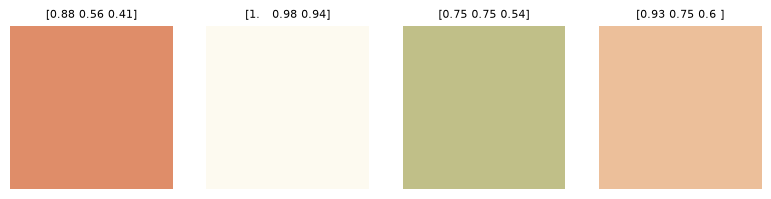

In [22]:
plot_dominant_colors(extract_dominant_colors(img, k=4))



In [23]:
#next phase; DALTONIZATION (CORRECTION)
from src.daltonize import daltonize, PROTANOPIA_CORRECTION_MATRIX


In [24]:
corrected = daltonize(img, PROTANOPIA_MATRIX, PROTANOPIA_CORRECTION_MATRIX)

before = accessibility_score(img, PROTANOPIA_MATRIX, k=4)
after = accessibility_score(corrected, PROTANOPIA_MATRIX, k=4)
print_accessibility_report(before, "before correction")
print_accessibility_report(after, "after correction")

--- Accessibility Report: before correction ---
Overall score (worst-case pair Delta-E): 6.92
No critically confusable pair found

  normal_diff= 19.72  cvd_diff=  6.92  colors=[0.75 0.75 0.54] vs [0.93 0.75 0.6 ]
  normal_diff= 37.01  cvd_diff= 15.35  colors=[0.88 0.56 0.41] vs [0.75 0.75 0.54]
  normal_diff= 22.73  cvd_diff= 17.16  colors=[0.88 0.56 0.41] vs [0.93 0.75 0.6 ]
  normal_diff= 28.83  cvd_diff= 26.18  colors=[1.   0.98 0.94] vs [0.93 0.75 0.6 ]
  normal_diff= 32.46  cvd_diff= 32.31  colors=[1.   0.98 0.94] vs [0.75 0.75 0.54]
  normal_diff= 49.98  cvd_diff= 41.69  colors=[0.88 0.56 0.41] vs [1.   0.98 0.94]
--- Accessibility Report: after correction ---
Overall score (worst-case pair Delta-E): 27.93
No critically confusable pair found

  normal_diff= 26.15  cvd_diff= 27.93  colors=[0.86 0.38 1.  ] vs [0.87 0.56 1.  ]
  normal_diff= 32.20  cvd_diff= 30.93  colors=[0.93 0.75 1.  ] vs [0.87 0.56 1.  ]
  normal_diff= 42.96  cvd_diff= 39.13  colors=[0.94 0.92 0.87] vs [0.93 0.

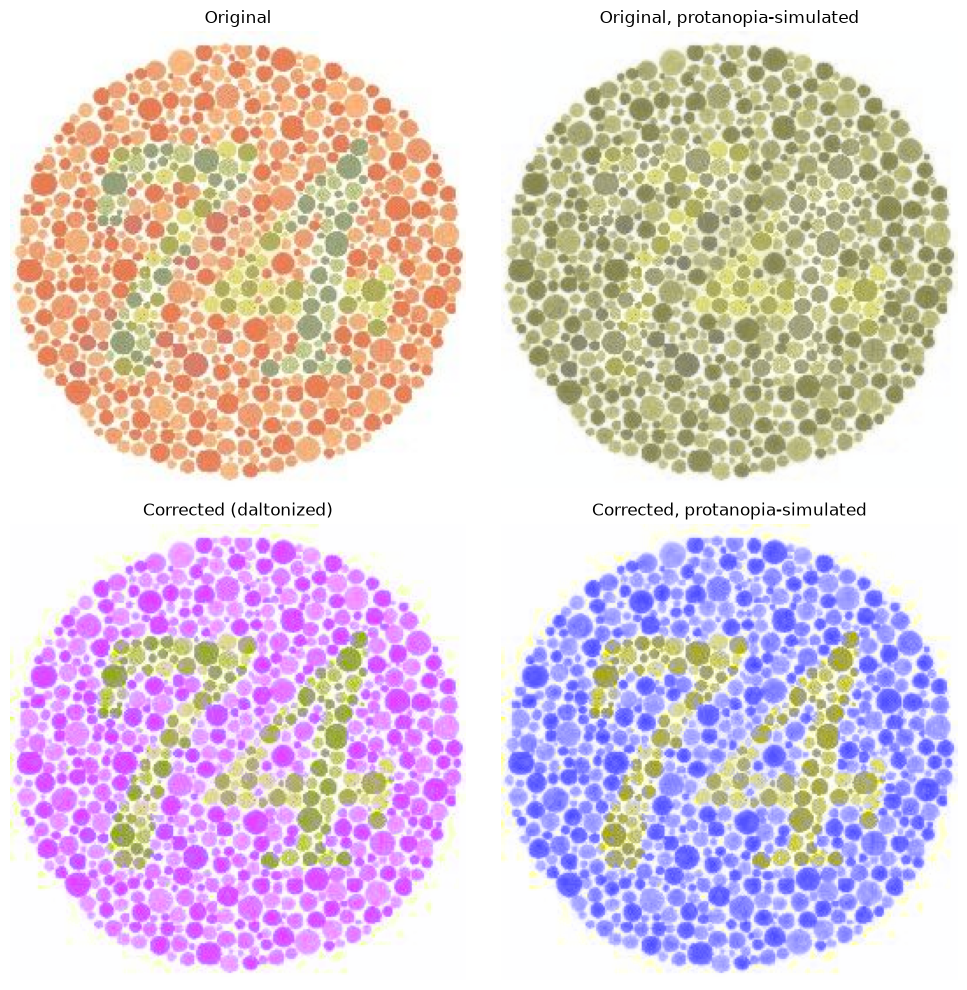

In [25]:
simulated_original = simulate_cvd(img, PROTANOPIA_MATRIX)
simulated_corrected = simulate_cvd(corrected, PROTANOPIA_MATRIX)

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes[0,0].imshow(np.clip(img, 0, 1))
axes[0,0].set_title('Original')
axes[0,1].imshow(np.clip(simulated_original, 0, 1))
axes[0,1].set_title('Original, protanopia-simulated')
axes[1,0].imshow(np.clip(corrected, 0, 1))
axes[1,0].set_title('Corrected (daltonized)')
axes[1,1].imshow(np.clip(simulated_corrected, 0, 1))
axes[1,1].set_title('Corrected, protanopia-simulated')

for ax in axes.flat:
    ax.axis('off')
plt.tight_layout()
plt.show()

In [26]:
#the correction is proportional to how much a color relies on the compromised cone
#red/orange bg was L-heavy so it received most redistribution from the daltonization

In [27]:
#quick sanity check on unet

import torch
from src.Unet import SmallUNet

In [28]:
model = SmallUNet()
dummy_input = torch.randn(1, 3, 256, 256)  # batch=1, RGB, 256x256
output = model(dummy_input)
print(output.shape)  # should be torch.Size([1, 3, 256, 256])

torch.Size([1, 3, 256, 256])


In [29]:
#good, unet's architecture is sound

In [30]:
from src.train import train
from src.differentiable import PROTANOPIA_MATRIX_TORCH

In [31]:
import cv2
img_resized = cv2.resize(img, (256, 256))  # size divisible by 8
img_tensor = torch.tensor(img_resized, dtype=torch.float32).permute(2, 0, 1).unsqueeze(0)

In [32]:
img_tensor = torch.tensor(img_resized, dtype=torch.float32).permute(2, 0, 1).unsqueeze(0)  # (H,W,3) -> (1,3,H,W)

model = train(img_tensor, cvd_matrix=PROTANOPIA_MATRIX_TORCH, epochs=200)

epoch    0  loss=0.6443  distortion=0.6645  accessibility_gain=0.2018
epoch   20  loss=0.2158  distortion=0.2531  accessibility_gain=0.3727
epoch   40  loss=0.0876  distortion=0.1229  accessibility_gain=0.3528
epoch   60  loss=0.0292  distortion=0.0660  accessibility_gain=0.3678
epoch   80  loss=0.0019  distortion=0.0391  accessibility_gain=0.3712
epoch  100  loss=-0.0092  distortion=0.0281  accessibility_gain=0.3729
epoch  120  loss=-0.0133  distortion=0.0243  accessibility_gain=0.3756
epoch  140  loss=-0.0148  distortion=0.0231  accessibility_gain=0.3785
epoch  160  loss=-0.0154  distortion=0.0226  accessibility_gain=0.3794
epoch  180  loss=-0.0156  distortion=0.0223  accessibility_gain=0.3797
epoch  199  loss=-0.0158  distortion=0.0222  accessibility_gain=0.3800

Loaded checkpoint with lowest distortion: 0.0222


In [33]:
model.eval()
with torch.no_grad():
    corrected_unet = model(img_tensor).squeeze(0).permute(1,2,0).numpy()

from src.metrics import accessibility_score, print_accessibility_report
result = accessibility_score(corrected_unet, PROTANOPIA_MATRIX, k=4)
print_accessibility_report(result, "U-Net corrected")

--- Accessibility Report: U-Net corrected ---
Overall score (worst-case pair Delta-E): 31.48
No critically confusable pair found

  normal_diff= 35.16  cvd_diff= 31.48  colors=[0.85 0.44 0.52] vs [0.95 0.72 0.91]
  normal_diff= 39.36  cvd_diff= 39.34  colors=[1.   1.   0.89] vs [0.91 0.91 0.5 ]
  normal_diff= 48.59  cvd_diff= 42.90  colors=[1.   1.   0.89] vs [0.95 0.72 0.91]
  normal_diff= 62.71  cvd_diff= 51.58  colors=[1.   1.   0.89] vs [0.85 0.44 0.52]
  normal_diff= 78.36  cvd_diff= 69.71  colors=[0.85 0.44 0.52] vs [0.91 0.91 0.5 ]
  normal_diff= 80.27  cvd_diff= 76.37  colors=[0.95 0.72 0.91] vs [0.91 0.91 0.5 ]


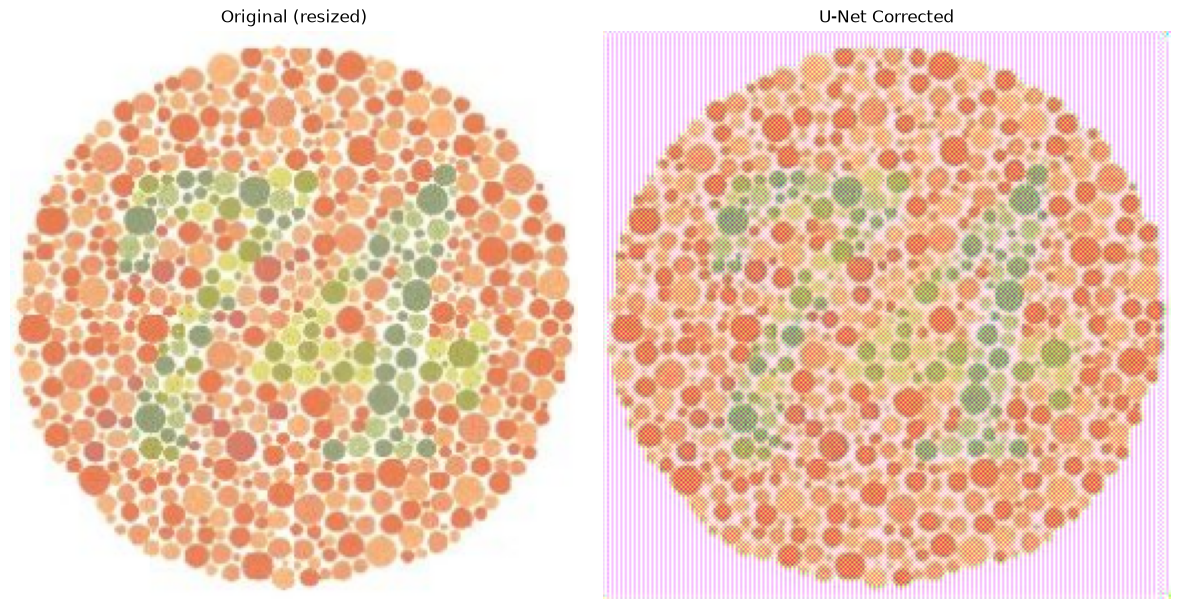

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(np.clip(img_resized, 0, 1))
axes[0].set_title('Original (resized)')
axes[1].imshow(np.clip(corrected_unet, 0, 1))
axes[1].set_title('U-Net Corrected')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()